In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score , KFold

In [3]:
df = pd.read_csv('loanapproval.csv')
label_encoder = LabelEncoder()

In [4]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [5]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='str')

In [39]:
df.nunique()

applicant_id            1000
age                       44
gender                     2
marital_status             3
annual_income            996
loan_amount              990
credit_score             452
num_dependents             5
existing_loans_count       5
employment_status          3
loan_approved              2
dtype: int64

In [6]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [7]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   applicant_id          1000 non-null   int64
 1   age                   1000 non-null   int64
 2   gender                1000 non-null   str  
 3   marital_status        1000 non-null   str  
 4   annual_income         1000 non-null   int64
 5   loan_amount           1000 non-null   int64
 6   credit_score          1000 non-null   int64
 7   num_dependents        1000 non-null   int64
 8   existing_loans_count  1000 non-null   int64
 9   employment_status     1000 non-null   str  
 10  loan_approved         1000 non-null   int64
dtypes: int64(8), str(3)
memory usage: 107.9 KB


In [9]:
df['gender'] = label_encoder.fit_transform(df['gender'])
df['marital_status'] = label_encoder.fit_transform(df['marital_status'])
df['employment_status'] = label_encoder.fit_transform(df['employment_status'])

In [10]:
correlation = df.drop('loan_approved',axis=1)
correlation.corr()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status
applicant_id,1.000000,-0.041905,-0.010904,0.003483,0.075261,0.013564,-0.027069,-0.085307,-0.000201,0.037934
age,-0.041905,1.000000,-0.040327,-0.052426,0.002591,0.000235,0.052769,-0.031510,0.063977,0.017699
gender,-0.010904,-0.040327,1.000000,-0.078468,0.010925,-0.017831,0.013536,-0.032406,0.034001,-0.005564
marital_status,0.003483,-0.052426,-0.078468,1.000000,-0.038886,0.023516,-0.003239,-0.026466,0.027671,-0.014520
annual_income,0.075261,0.002591,0.010925,-0.038886,1.000000,-0.024862,0.016921,-0.016445,-0.010745,0.040909
loan_amount,0.013564,0.000235,-0.017831,0.023516,-0.024862,1.000000,0.044939,0.037140,-0.012043,-0.016806
credit_score,-0.027069,0.052769,0.013536,-0.003239,0.016921,0.044939,1.000000,-0.067063,0.017398,-0.053793
num_dependents,-0.085307,-0.031510,-0.032406,-0.026466,-0.016445,0.037140,-0.067063,1.000000,0.046405,-0.040916
existing_loans_count,-0.000201,0.063977,0.034001,0.027671,-0.010745,-0.012043,0.017398,0.046405,1.000000,-0.003003
employment_status,0.037934,0.017699,-0.005564,-0.014520,0.040909,-0.016806,-0.053793,-0.040916,-0.003003,1.000000


# Correlation

<Axes: >

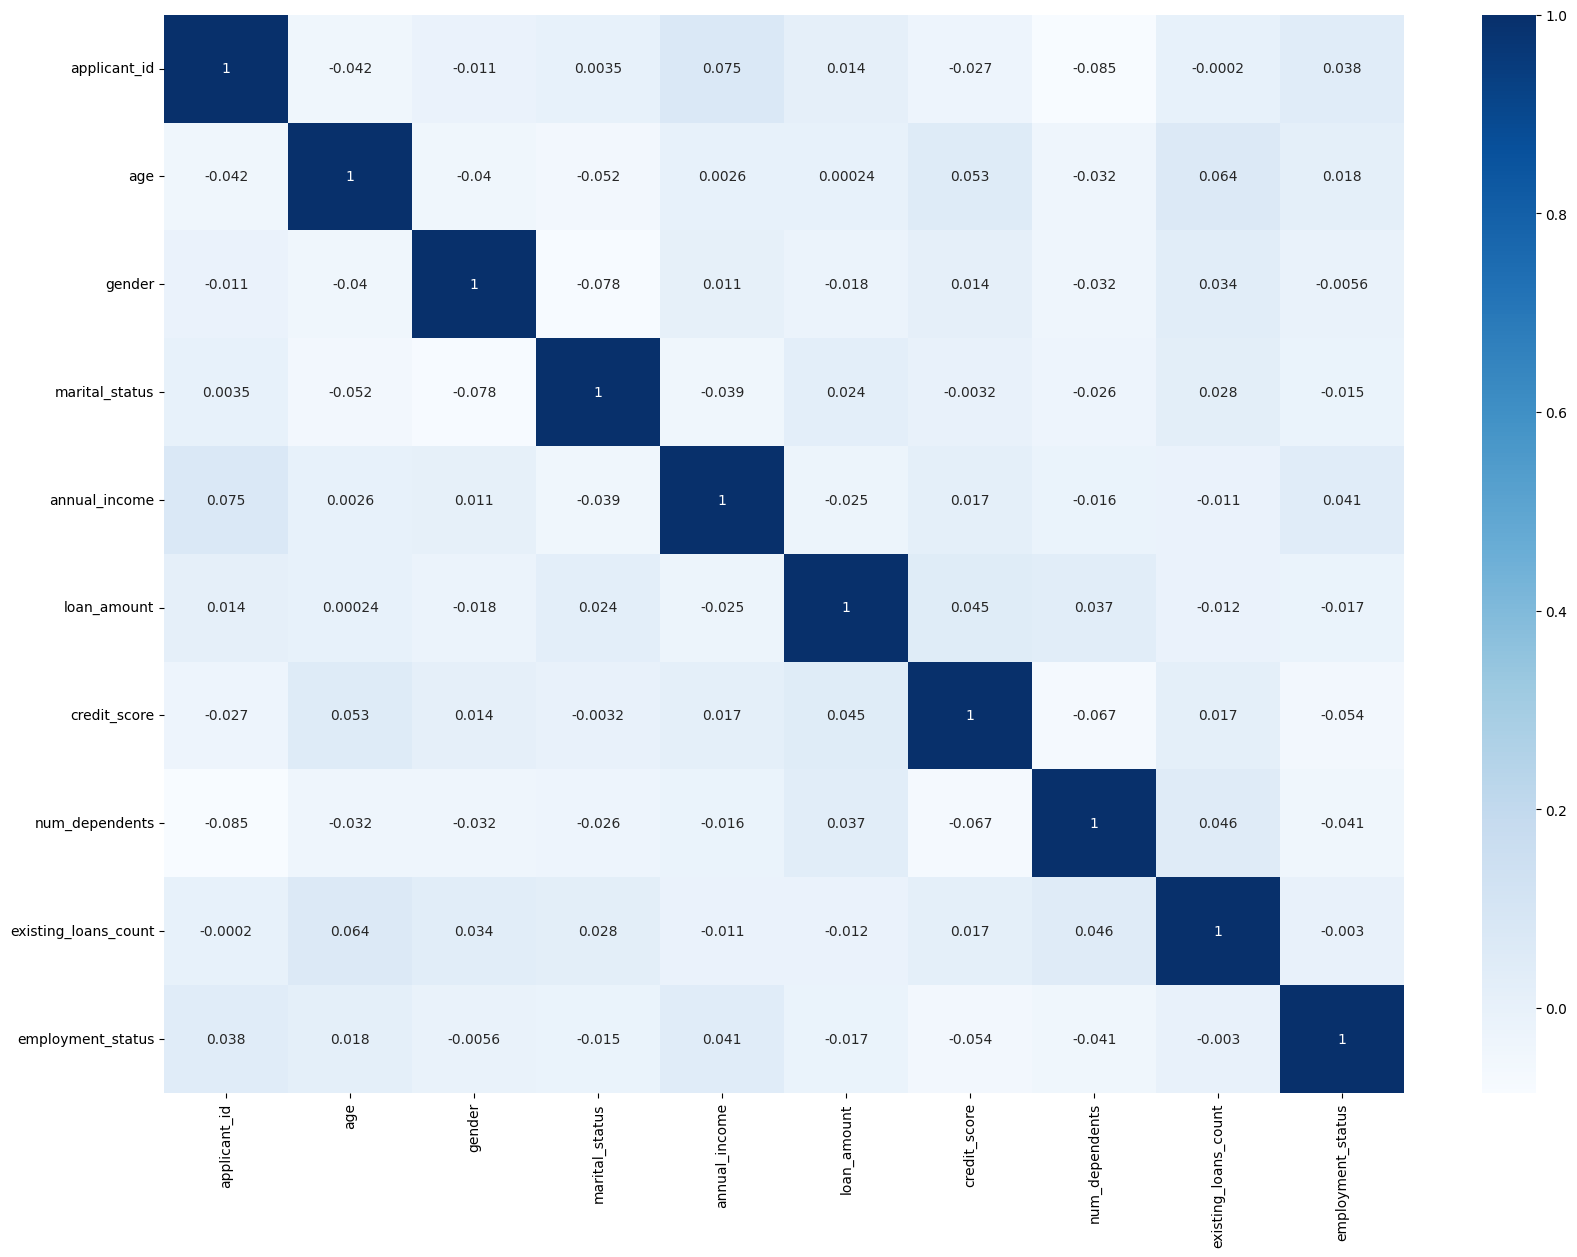

In [11]:
plt.figure(figsize=(20,14))

sns.heatmap(correlation.corr(),annot=True,cmap='Blues')

# Number of lons approved vs not approved

In [12]:
# counts = df['loan_approved'].value_counts()
# plt.bar(counts.index, counts.values)
# plt.show()

df['loan_approved']

0      1
1      1
2      0
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: loan_approved, Length: 1000, dtype: int64

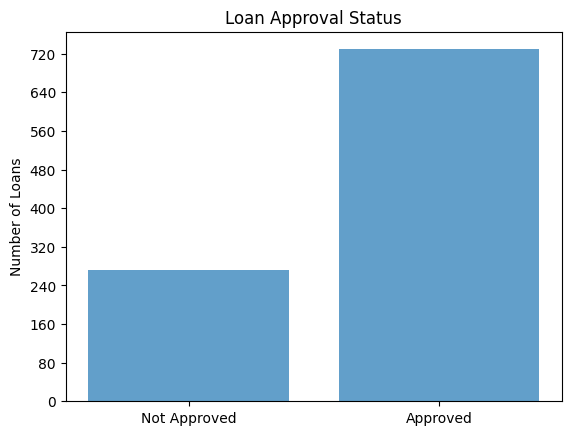

In [14]:
from matplotlib.ticker import MaxNLocator

counts = df['loan_approved'].value_counts().sort_index()

plt.bar(['Not Approved', 'Approved'], counts, alpha=0.7)

plt.title("Loan Approval Status")
plt.ylabel("Number of Loans")

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

# Loan Approved weither someone is married or no

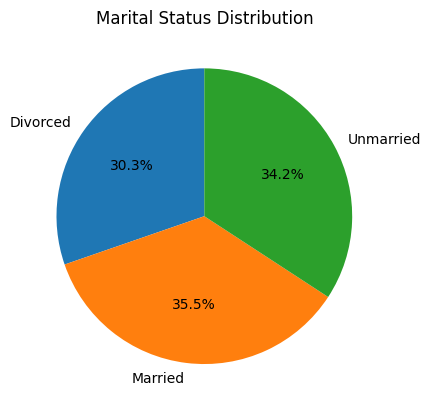

In [44]:

# 0 divorced
# 1 Married
# 2 un married



import matplotlib.pyplot as plt


counts = df['marital_status'].value_counts().sort_index()

labels = ['Divorced', 'Married', 'Unmarried']

fig, ax = plt.subplots()
ax.pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title("Marital Status Distribution")
plt.show()


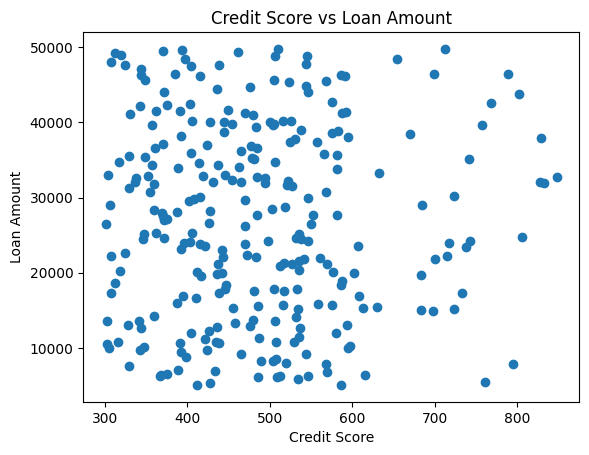

In [50]:
loan_approved = df[df['loan_approved'] == 0]

plt.scatter(loan_approved['credit_score'], loan_approved['loan_amount'])
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.title("Credit Score vs Loan Amount")
plt.show()

# Annual Income against loan amount

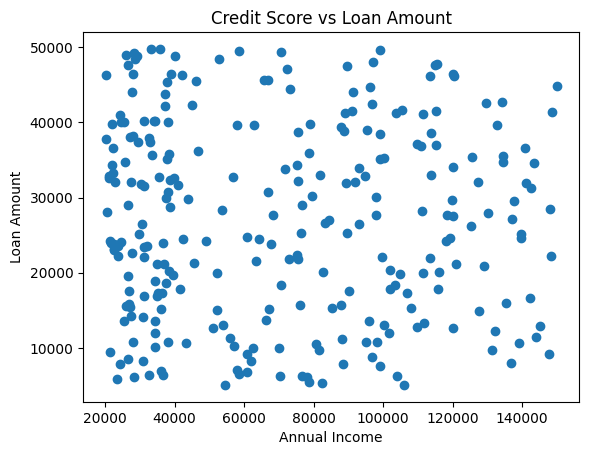

In [52]:
loan_approved = df[df['loan_approved'] == 0]

plt.scatter(loan_approved['annual_income'], loan_approved['loan_amount'])
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Credit Score vs Loan Amount")
plt.show()

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

feature = df.drop("loan_approved",axis=1).values
target = df["loan_approved"].values

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.4,random_state=42)


knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[ 27  81]
 [ 26 266]]
              precision    recall  f1-score   support

           0       0.51      0.25      0.34       108
           1       0.77      0.91      0.83       292

    accuracy                           0.73       400
   macro avg       0.64      0.58      0.58       400
weighted avg       0.70      0.73      0.70       400



# Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=100)
X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.4,random_state=42)

logreg.fit(X_train,y_train)
y_pred = logreg.predict(X_test)
print(y_pred)
y_pred_probs = logreg.predict_log_proba(X_test)[:,1]
print(y_pred_probs[0])



[0 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1
 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1
 1 1 1 1 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1
 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 0
 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1
 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0
 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 1]
-0.8206106704304387


/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


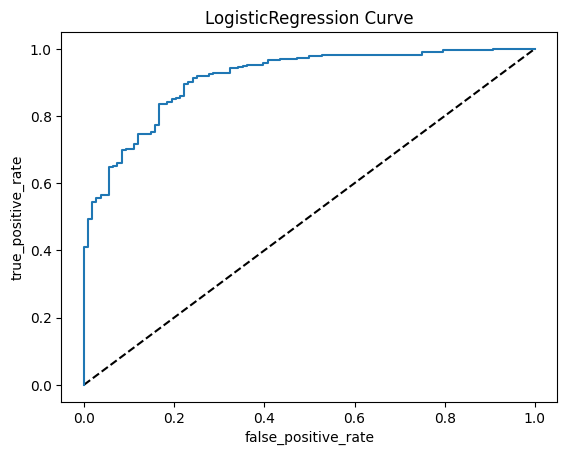

In [60]:
from sklearn.metrics import roc_curve
false_positive_rate , true_positive_rate , thresholds = roc_curve(y_test,y_pred_probs)

plt.plot([0,1],[0,1],'k--')
plt.plot(false_positive_rate,true_positive_rate)
plt.xlabel('false_positive_rate')
plt.ylabel('true_positive_rate')
plt.title("LogisticRegression Curve")
plt.show()


# Performance

In [61]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test,y_pred_probs))

0.9122590055809234


In [62]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test , y_pred)

0.36055512754639896

# Tuning the hyperparameter

# Ridge Regression

In [64]:
from sklearn.linear_model import Ridge
scores = []

for alpha in [0.1,1.0,10,100,1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    y_pred = ridge.predict(X_test)
    scores.append(ridge.score(X_test,y_test))

print(scores)

[0.42522814017104393, 0.4252612101848344, 0.42552280122123665, 0.42338391805354847, 0.34716588661254]


# Lasso Regression

In [66]:
from sklearn.linear_model import Lasso
scores = []
for alpha in [0.1,1.0,10,100,1000]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train,y_train)
    y_pred = lasso.predict(X_test)
    scores.append(lasso.score(X_test,y_test))

print(scores)

print(np.mean(scores),np.std(scores))

[0.3046120780193844, 0.1364545079713798, 0.12412697748416168, 0.030261284297722457, 0.027465489113590924]
0.12458406737724785 0.10087616820503806


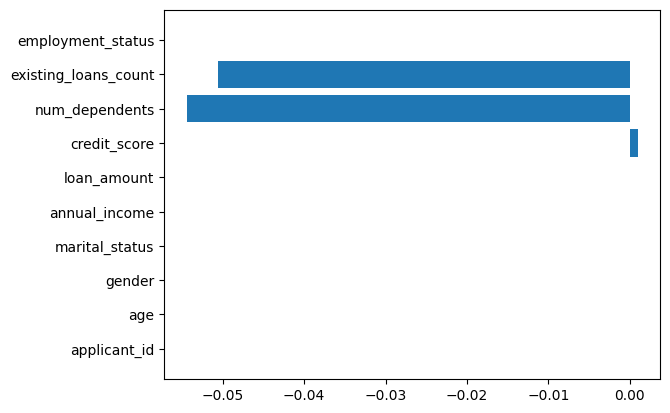

In [ ]:
from sklearn.linear_model import Lasso

X = df.drop("loan_approved",axis=1).values
Y = df["loan_approved"].values
names = df.drop("loan_approved",axis=1).columns
lasso = Lasso(alpha=0.1)
lasso_coef = lasso.fit(X,Y).coef_

plt.barh(names,lasso_coef)
# plt.xticks(rotation=45)
plt.show()

In [69]:
X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/var/folders/6x/cw89xb1x1f7c87g5_m1hrq040000gn/T/ipykernel_81757/3802901423.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results,labels=models.keys())


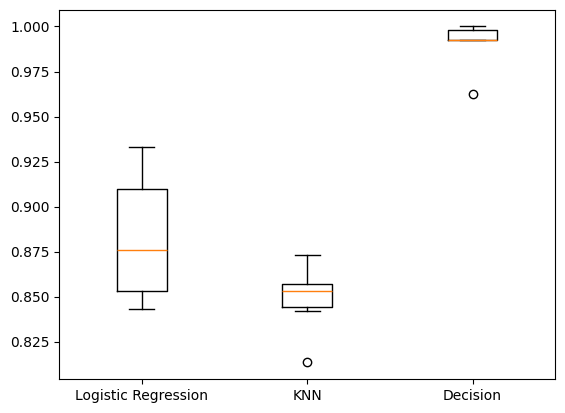

In [71]:
models = {"Logistic Regression" : LogisticRegression(),
          "KNN" : KNeighborsClassifier(),
          "Decision" : DecisionTreeClassifier()}

results = []

for model in models.values() :
    kf = KFold(n_splits=6,random_state=42,shuffle=True)
    cv_results = cross_val_score(model,X_trained_scaled,y_train,cv=kf)
    results.append(cv_results)
plt.boxplot(results,labels=models.keys())
plt.show()

In [72]:
for name , model in models.items() :
    model.fit(X_trained_scaled,y_train)
    test_score = model.score(X_test_scaled,y_test)
    print("{} Test score accuracy: {}".format(name,test_score))

Logistic Regression Test score accuracy: 0.83
KNN Test score accuracy: 0.87
Decision Test score accuracy: 0.98
